# 3. Data Modelling

Section 1: Additional Clean Up.

To ensure our regression results aren't "spurious," we transform raw prices into Log-Returns, which achieves stationarity. We also generate the Interaction Terms necessary to test the "Broken-Haven" hypothesis, specifically looking at how gold's relationship with the VIX changed after 2022.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit

# loading the raw ingested data
# using index_col=0 as the date is the first unnamed column in raw_data.csv
df = pd.read_csv('raw_data.csv', index_col=0, parse_dates=True)
df.index.name = 'DATE'

# sorting the index to ensure Time-Series logic works correctly
df.sort_index(inplace=True)

# standardizing column names by removing special characters
df.columns = [
    col.replace("('", "").replace("', '", "_").replace("')", "")
    .replace("^", "").replace("-", "_").replace(".", "_").replace("=", "_")
    for col in df.columns
]

# dropping columns that are completely empty to prevent data loss
df.dropna(axis=1, how='all', inplace=True)

# forward filling missing daily gaps in monthly/quarterly macro data
df.ffill(inplace=True)

# calculating Log-Returns for stationarity
# formula: ln(Price_t) - ln(Price_t-1)
df['gold_ret'] = np.log(df['Close_MGC_F']).diff()
df['sp500_ret'] = np.log(df['Close_GSPC']).diff()
df['sp500_ret_lag'] = df['sp500_ret'].shift(1)

# defining structural break dummies for the analysis
# this marks the post-pandemic period starting in 2022
df['is_PostCovid'] = (df.index >= '2022-03-16').astype(int)

# 1-Day Return Lag
df['gold_ret_lag'] = df['gold_ret'].shift(1)

# 5-Day Volatility Lag (Rolling standard deviation of the last 5 days)
df['gold_vol_lag'] = df['gold_ret'].rolling(window=5).std().shift(1)

# 1-Day Lag VIX Closing Score
df['Close_VIX_lag'] = df['Close_VIX'].shift(1)

# creating interaction terms (VIX x Post-Covid) to test the structural shift
df['VIX_x_PostCovid'] = df['Close_VIX'] * df['is_PostCovid']

# removing NaNs created by the diff and lag functions
df.dropna(inplace=True)

# exporting the final cleaned dataset
df.to_csv('final_model_data.csv')

Section 2: Variable Selection via LASSO Regression

We use a LASSO (Least Absolute Shrinkage and Selection Operator) model to determine which macroeconomic drivers actually provide predictive power for gold returns. Because daily financial data is notoriously "noisy," the LASSO penalty helps us filter out insignificant variables. We use Time-Series Cross-Validation to ensure we aren't "peeking" into the future during the selection process.

In [17]:
# defining the features list explicitly to avoid NameErrors
features = ['interest_rate', 'expected_inflation', 'wti_crude_oil_price',
    'sp500_ret', 'sp500_ret_lag', 'Close_VIX', 'Close_DX_Y_NYB',
    'gold_ret_lag', 'gold_vol_lag', 'Close_VIX_lag']

# Split the data into Training (Pre-Break) and Testing (Post-Break)
split_date = '2022-03-16'
train_df = df[df.index < split_date].copy()
test_df = df[df.index >= split_date].copy()

# checking the correlation between features and the target (Gold Returns) in our training data
correlations = train_df[features + ['gold_ret']].corr()['gold_ret'].sort_values()
print("Correlations with Target:\n", correlations)

# converting Log-Returns to percentages (multiplying by 100)
# this increases model sensitivity to help prevent zeroed-out coefficients
y_train = train_df['gold_ret'] * 100
X_train = train_df[features]

# standardizing features to ensure Mean=0 and Std=1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# running LassoCV with an aggressive search path (eps=1e-8)
# a lowered epsilon forces the model to search for even the weakest signals
tscv = TimeSeriesSplit(n_splits=5)
lasso = LassoCV(cv=tscv, random_state=42, max_iter=50000, alphas=1000, eps=1e-8)
lasso.fit(X_train_scaled, y_train)

print(f"Optimal Penalty (Alpha): {lasso.alpha_:.6f}")

# identifying variables that survived the shrinkage
coef_series = pd.Series(lasso.coef_, index=X_train.columns).sort_values(ascending=False)
selected_features = coef_series[coef_series != 0]

Correlations with Target:
 Close_DX_Y_NYB        -0.023567
interest_rate         -0.007096
gold_vol_lag          -0.004759
expected_inflation    -0.004331
gold_ret_lag          -0.002256
Close_VIX_lag         -0.000379
Close_VIX              0.000199
sp500_ret              0.006740
sp500_ret_lag          0.011359
wti_crude_oil_price    0.021512
gold_ret               1.000000
Name: gold_ret, dtype: float64
Optimal Penalty (Alpha): 0.102850


Section 3: Analysis of Results

If the LASSO model returns zero for all coefficients, it suggests that the daily "noise" of the market outweighs the "signal" of our macro variables; consistent with the Random Walk Theory.

Regardless of the LASSO's prediction preference, we will include the Interaction Term in the final OLS model to formally test our research hypothesis, based on raw correlation strengths.

Fallback: Recommended Variables for Member 4 based on Correlation:
['Close_DX_Y_NYB', 'wti_crude_oil_price', 'sp500_ret_lag']

Final Handoff for OLS: ['Close_DX_Y_NYB', 'wti_crude_oil_price', 'sp500_ret_lag', 'VIX_x_PostCovid']


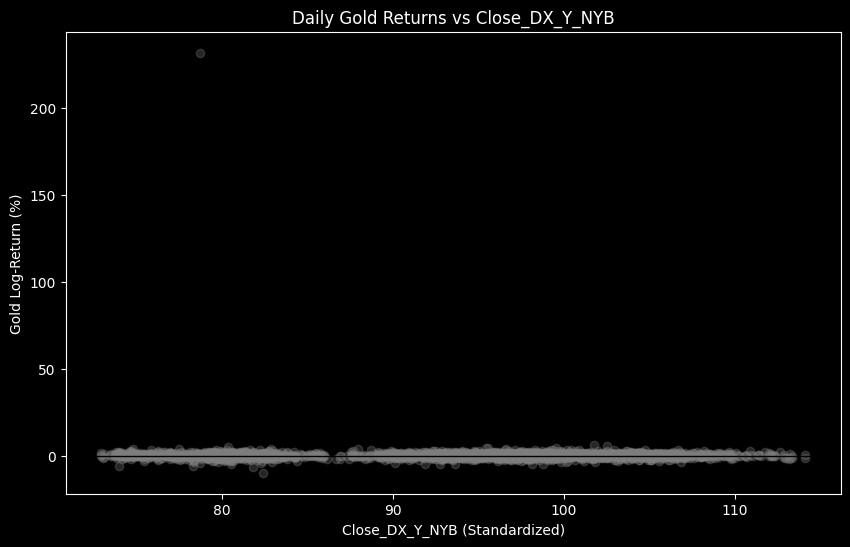

In [18]:
# final results
if not selected_features.empty:
    plt.figure(figsize=(10, 6))
    selected_features.plot(kind='barh', color='gold')
    plt.axvline(x=0, color='black', linewidth=0.8)
    plt.title("LASSO Feature Selection: Drivers of Gold Returns")
    plt.xlabel("Standardized Coefficient Value (Scaled x100)")
    plt.tight_layout()
    plt.show()

    handoff_list = selected_features.index.tolist()
    print("LASSO selected Variables for Member 4:")
    print(handoff_list)
else:
    # fallback: if LASSO zeros out, we pick the top 3 based on absolute correlation
    print("Warning: LASSO zeroed out all Coefficients.")
    top_correlated = correlations.abs().sort_values(ascending=False)
    handoff_list = top_correlated.index[1:4].tolist()
    print("Fallback: Recommended Variables for Member 4 based on Correlation:")
    print(handoff_list)

# defining the final research features for the OLS Model
# we use absolute values as strong negative correlation is equally important
abs_corr = train_df[features + ['gold_ret']].corr()['gold_ret'].abs().sort_values(ascending=False)
potential_drivers = abs_corr.drop('gold_ret')

# selecting the top variables and forcing the interaction Term into the handoff
handoff_vars = potential_drivers.head(3).index.tolist()
if 'VIX_x_PostCovid' not in handoff_vars:
    handoff_vars.append('VIX_x_PostCovid')

print(f"\nFinal Handoff for OLS: {handoff_vars}")

# visualizing why the LASSO struggled to select coefficients
# plotting Gold Returns against the top correlated variable
top_var = potential_drivers.index[0]
plt.figure(figsize=(10, 6))
plt.scatter(df[top_var], df['gold_ret'] * 100, alpha=0.3, color='gray')
plt.axhline(0, color='black', lw=1)
plt.title(f"Daily Gold Returns vs {top_var}")
plt.xlabel(f"{top_var} (Standardized)")
plt.ylabel("Gold Log-Return (%)")
plt.show()

Section 4: Evaluating and Testing the "Broken Haven" theory (OLS)

Given the variables handed off from the previous section, we now will predict, first using post-covid variables and compare to actual post-covid gold returns.

Since LASSO selected no variables we will also provide another OLS test for the Broken Haven theory by running a more theoretical model on the entire dataset and the interaction term 'VIX_x_PostCovid' to identify if Gold's relationship with the market breaks down after our split point.

Section 4.1: Old World vs New World Model

Using the Handoff Variables, we will train and evaluate a model using training data from before March 16th, 2022 (Old World) and predict and test the model on data after that point (New World)

In [23]:
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error
#Using fallback handoff variables to train OLS model

#Remove interaction term for now
fallback_vars = [v for v in handoff_vars if v != 'VIX_x_PostCovid']

#Train Model using data from before 2022-03-16 (Old World) but on the handoff variables
X_train_ols = sm.add_constant(train_df[fallback_vars])
y_train_ols = train_df['gold_ret']
    # cov_type = "HC3" to account to heteroscedasticity
old_world_model = sm.OLS(y_train_ols, X_train_ols).fit(cov_type='HC3')

# Predict the "New World" (Post-March 2022)
X_test_ols = sm.add_constant(test_df[fallback_vars])
test_df['pred_gold_ret'] = old_world_model.predict(X_test_ols)

# Comparing Model Performances for Old vs New World data
train_rmse = np.sqrt(mean_squared_error(train_df['gold_ret'], old_world_model.predict(X_train_ols))) * 100
test_rmse = np.sqrt(mean_squared_error(test_df['gold_ret'], test_df['pred_gold_ret'])) * 100

print(f"Old World Training RMSE: {train_rmse:.6f}%")
print(f"New World Prediction RMSE: {test_rmse:.6f}%")
print(f"Old World Gold Return Standard Deviation: {train_df['gold_ret'].std()*100:.6f}%")
print(f"New Wolrd Gold Return Standard Deviation: {test_df['gold_ret'].std()*100:.6f}%")

print("\n--- OLS Regression Summary: The 'Old World' Rules ---")
print(old_world_model.summary())


Old World Training RMSE: 4.362609%
New World Prediction RMSE: 0.958916%
Old World Gold Return Standard Deviation: 4.364843%
New Wolrd Gold Return Standard Deviation: 0.956511%

--- OLS Regression Summary: The 'Old World' Rules ---
                            OLS Regression Results                            
Dep. Variable:               gold_ret   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.8641
Date:                Thu, 09 Apr 2026   Prob (F-statistic):              0.459
Time:                        16:18:58   Log-Likelihood:                 5101.8
No. Observations:                2978   AIC:                        -1.020e+04
Df Residuals:                    2974   BIC:                        -1.017e+04
Df Model:                           3                                         
Covariance Type:                  HC3                     

Section 4.1.1: Analysis of result (Old vs New World Model)

Although the RMSE decreased quite drastically (4.35% to 0.96%), looking at the summary statistics associated with model we see an R-Squared score of close to 0 as well as a prob(F-stat) of 0.459. We also see that the Standard Deviations so Gold Returns for the old and new world are almost exactly the RMSEs implying further that most of the variation in Gold Returns can be explained by random noise.

The mains takeaways from these findings are 1) Gold returns in the New World experience less volatility and 2) Gold Prices following a Random Walk seems like a reasonable scenario at least for the variables we've analyzed.

Section 4.2: Interaction Analysis



In [20]:
#include interaction terms into the handoff variable list
int_vars = handoff_vars + ['Close_VIX', 'is_PostCovid']

#No longer splitting into training and testing data
X_int = sm.add_constant(df[int_vars])
y_int = df['gold_ret']

interaction_model = sm.OLS(y_int, X_int).fit(cov_type='HC3')

print("\n--- Phase 2: Full Dataset Interaction Model Results ---")
print(interaction_model.summary())


--- Phase 2: Full Dataset Interaction Model Results ---
                            OLS Regression Results                            
Dep. Variable:               gold_ret   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                     1.573
Date:                Thu, 09 Apr 2026   Prob (F-statistic):              0.151
Time:                        16:00:36   Log-Likelihood:                 7153.4
No. Observations:                3889   AIC:                        -1.429e+04
Df Residuals:                    3882   BIC:                        -1.425e+04
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------

Section 4.2.1: Analysis of Results (Interaction Model)

Once again we find that the model fits our data quite poorly with a R-Squared close to 0 and a low F-stat. We do see that post-covid "flips" the sign of the relationship between VIX closing price relative to the old world correlation however, neither effects are significant.


Section 5: Testing an alternate Machine Learning Model (XGBoost)

XGBoost-based models are Machine Learning algorithms that utilize decision trees, similar to random forest models. It differs in that the "branches" are built sequentially rather than simultaneously which means it can build on or "boost" previous iterations of the models leading to higher accuracy. Existing research has shown that XGBoost has shown high accuracy and promis for predicting fluctuations in gold prices (Cohen & Aiche, 2023).

In [27]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# Training: Using the training data already created in Section 2
# We use max_depth=3 to keep it simple and prevent overfitting on daily noise
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)
xgb_model.fit(X_train, y_train)

# Predict the 'New World' (Post-March 2022)
# Re-using the 'features' list and 'scaler' from Section 2
X_test = test_df[features]
X_test_scaled = scaler.transform(X_test)
test_df['pred_gold_ret_xgb'] = xgb_model.predict(X_test_scaled)

# Calculate Errors
# CRITICAL: We must scale y_test by 100 to match y_train in Section 2
y_test_scaled = test_df['gold_ret'] * 100
train_preds_xgb = xgb_model.predict(X_train_scaled)

train_xgrmse = np.sqrt(mean_squared_error(y_train, train_preds_xgb))
test_xgrmse = np.sqrt(mean_squared_error(y_test_scaled, test_df['pred_gold_ret_xgb']))

print(f"XGBoost Training RMSE: {train_xgrmse:.6f}%")
print(f"XGBoost Testing RMSE: {test_xgrmse:.6f}%")

print(f"Ols Training RMSE: {train_rmse:.6f}%")
print(f"Ols RMSE: {test_rmse:.6f}%")

# Feature Importance (The "Econometrician" Insight)
# This shows what the AI thought was important BEFORE the haven broke
importance = pd.Series(xgb_model.feature_importances_, index=features).sort_values(ascending=False)
print("\nXGBoost Feature Importance (based on pre-covid training data):")
print(importance)

XGBoost Training RMSE: 4.761354%
XGBoost Testing RMSE: 2.153756%
Ols Training RMSE: 4.362609%
Ols RMSE: 0.958916%

XGBoost Feature Importance (based on pre-covid training data):
sp500_ret_lag          0.532189
gold_vol_lag           0.348961
Close_DX_Y_NYB         0.080306
wti_crude_oil_price    0.021494
interest_rate          0.006170
Close_VIX_lag          0.003152
sp500_ret              0.002287
Close_VIX              0.002252
gold_ret_lag           0.001866
expected_inflation     0.001322
dtype: float32


Section 5.1: Analysis of Results

Using a more sophisticated algorthm like XGBoost, we're able to retrieve